**MNIST CNN Classifier From Scratch**

In [1]:
import numpy as np 
from keras import datasets
import matplotlib.pyplot as plt 
from random import random

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data(path = 'mnist.npz')

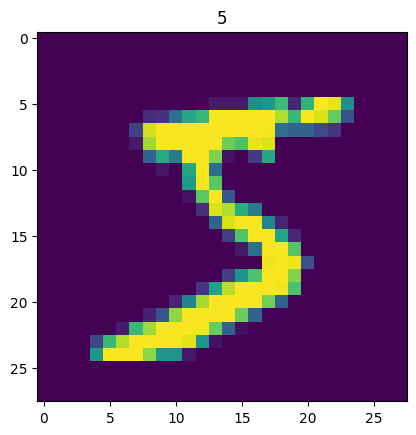

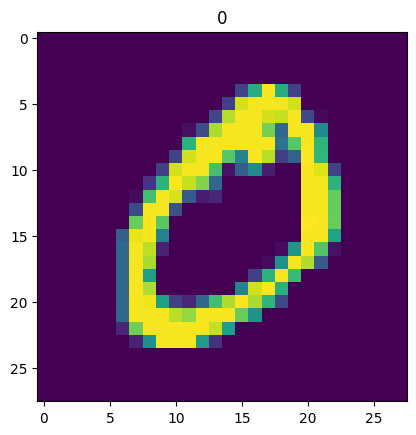

(60000, 28, 28)


In [3]:
for i in range(2):
    plt.imshow(x_train[i])
    plt.title(y_train[i])
    plt.show()

print(x_train.shape)

In [4]:
# Reshape the data into a 784-length vector for input
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Map the data to [0, 1]
x_train = x_train / 255 
x_test = x_test / 255

In [5]:
def sigmoid(x: float) -> float:
    return 1 / (1 + np.exp(-x))

def sigmoidDerivative(x: float) -> float:
    return np.exp(-x) / (1 + np.exp(-x))**2

def relu(x: float) -> float:
    return np.max([0, x])

def reluDerivative(x: float) -> float:
    return np.max([0, x]) / x

def tanh(x: float) -> float:
    return np.tanh(x)

def tanhDerivative(x: float) -> float:
    return 1 - (np.tanh(x))**2

def softmax(x: float, x_sum: float) -> float:
    return np.exp(x) / x_sum

def softmaxDerivative(x: float, y: float, x_sum: float, x_index: int, y_index: int) -> float:
    if x_index == y_index:
        return softmax(x, x_sum) * (1 - softmax(y, x_sum))
    
    else:
        return -1 * softmax(x, x_sum) * softmax(y, x_sum)

In [ ]:
class Network():
    def __init__(self, 
                 input: list[float], 
                 weights: list[float], 
                 biases: list[float], 
                 layer_count: int, 
                 layer_shapes: list[int],
                 layer_activations: list[str]) -> None:
        
        self.input = input 
        self.weights = weights 
        self.biases = biases
        self.layer_count = layer_count
        self.layer_shapes = layer_shapes
        self.layer_activations = layer_activations


    def activator(self, x: list[float], type: str) -> float:
        if type.lower() == 'sigmoid':
            f = np.vectorize(sigmoid)
        
        if type.lower() == 'relu':
           f = np.vectorize(relu)
            
        if type.lower() == 'tanh':
            f = np.vectorize(tanh)
        
        if type.lower() == 'softmax':
            f = np.vectorize(softmax)
            return f(x, x_sum = np.sum(np.exp(x)))

        return f(x)
    

    def activatorDerivative(self, x: list[float], type: str) -> float:
        if type.lower() == 'sigmoid':
            f = np.vectorize(sigmoidDerivative)
        
        if type.lower() == 'relu':
           f = np.vectorize(reluDerivative)
            
        if type.lower() == 'tanh':
            f = np.vectorize(tanhDerivative)
        
        if type.lower() == 'softmax':
            out = np.zeros(len(x))
            for l in range(len(x)):
                for m in range(len(x)):
                    out[l] = softmaxDerivative(x[l], x[m], x_sum = np.sum(np.exp(x)), x_index=l, y_index=m)
            return out


        return f(x)    
        


    def feedForward(self, layer_input: list[float], layer_num: int) -> tuple[float]:
        node_val = (np.dot(self.weights[layer_num], layer_input) + self.biases[layer_num])
        return node_val


    def processor(self):
        # Check that layer counts match 
        if self.layer_count != len(self.layer_shapes):
            raise TypeError(f'Layer count ({self.layer_count}) and number of layer shapes given ({len(self.layer_shapes)}) do not match.')


        #Step 1: Check if the number of weights, biases and layers match
        if len(self.weights) != self.layer_count - 1:
            raise TypeError(f'Number of weight matrices should match the number of layers - 1 (no weights included in the output).')
        if len(self.biases)  != len(self.weights):
            raise TypeError(f'Number of bias matrices should match the number of layers - 1 (no weights included in the output).')

        # Step 2: Initiate a while loop to compute through each layer 
        i = 0
        layer_in = self.input
        all_nodes_post = [layer_in]
        while i < self.layer_count:
            if (i + 1 >= self.layer_count):
                break


            infeed_shape = self.layer_shapes[i]
            outfeed_shape = self.layer_shapes[i+1]

            if np.shape(self.weights[i]) != (outfeed_shape, infeed_shape):
                raise TypeError(f'Shape of weights does not match shape of given network layer(s).')
            if len(self.biases[i]) != outfeed_shape:
                raise TypeError(f'Shape of biases does not match shape of given network layer.')


            pre_activation = self.feedForward(layer_input = layer_in, layer_num = i)     
            post_activation = self.activator(x = pre_activation, type = self.layer_activations[i])


            layer_in = post_activation
            all_nodes_post.append(post_activation)

            i += 1

        return all_nodes_post

In [ ]:
# Load a sample input vector (length 748)
input_vector = np.array(x_train[0])

# Define the node counts per layer of the network
layers = [len(input_vector), 16, len(set(y_train))]

# Initialize weights with Kaiming / Xavier initialization (no exploding gradients please)
weights_01 = np.random.randn(layers[1], layers[0]) * np.sqrt(2.0 / layers[0])  
biases_01  = np.zeros(layers[1])
weights_12 = np.random.randn(layers[2], layers[1]) * np.sqrt(1.0 / layers[1]) 
biases_12  = np.zeros(layers[2])

In [8]:
# Function to convert the integer class to the correct vector 
def classToVector(output_class: int) -> list[int]:
    if (type(output_class) != int) or (output_class not in range(10)):
        raise TypeError(f'output_class must be an integer between 0 and 9.')    
    vec = np.zeros(10)
    vec[output_class] = 1
    return vec

In [ ]:
# Train the model using backpropagation on the weights 
batch_size = 32
epochs = 5
learning_rate = 0.05
n = len(x_train)

# Iterate through dataset 5 times
for epoch in range(epochs):
    idx = np.random.permutation(n)
    total_loss = 0.0

    for start in range(0, n, batch_size):
        batch = idx[start:start+batch_size]

        # Initialize weight gradients 
        gW12 = np.zeros_like(weights_12); gb2 = np.zeros_like(biases_12)
        gW01 = np.zeros_like(weights_01); gb1 = np.zeros_like(biases_01)

        for r in batch:
            actual = classToVector(int(y_train[r]))
            x = np.array(x_train[r], dtype=np.float32).ravel() 

            y = Network(input=x,
                        weights=[weights_01, weights_12],
                        biases=[biases_01, biases_12],
                        layer_count=len(layers),
                        layer_shapes=layers,
                        layer_activations=['relu', 'softmax'])
            post = y.processor()

            # Get all node values
            a0, a1, preds = post[0], post[1], post[2]

            # First error calculation
            dz2 = preds - actual
            # Backpropagate the gradients between error and hidden layer nodes
            gW12 += np.outer(dz2, a1)
            gb2  += dz2

            # ReLU derivative: 1 where a1 > 0, else 0
            dz1 = (weights_12.T @ dz2) * (a1 > 0).astype(np.float32)
            # Backprop
            gW01 += np.outer(dz1, a0)
            gb1  += dz1

            # Compute cross-entropy total loss
            total_loss += -np.sum(actual * np.log(np.clip(preds, 1e-12, 1.0)))

        m = len(batch)
        # Update weights and biases using gradient descent
        weights_12 -= learning_rate * gW12 / m
        biases_12  -= learning_rate * gb2  / m
        weights_01 -= learning_rate * gW01 / m
        biases_01  -= learning_rate * gb1  / m

    print(f"epoch {epoch}  loss={total_loss/n:.4f}")

epoch 0  loss=0.4380
epoch 1  loss=0.2700
epoch 2  loss=0.2298
epoch 3  loss=0.2051
epoch 4  loss=0.1877


In [ ]:
# Test the network
for num in range(20):

    y = Network(input = x_train[num], 
                    weights = [weights_01, weights_12], 
                    biases = [biases_01, biases_12], 
                    layer_count = len(layers), 
                    layer_shapes = layers, 
                    layer_activations= ['relu', 'softmax'])

    all_nodes_post = y.processor()[0]
    pred = int(np.argmax(all_nodes_post[2]))
    print(pred, "true:", int(y_train[num]))

5 true: 5
0 true: 0
4 true: 4
1 true: 1
9 true: 9
2 true: 2
1 true: 1
3 true: 3
1 true: 1
4 true: 4
3 true: 3
5 true: 5
3 true: 3
6 true: 6
1 true: 1
7 true: 7
2 true: 2
8 true: 8
6 true: 6
9 true: 9


In [ ]:
# Compute accurary from x_test
correct = 0
N = len(x_test)
for k in range(N):
    x = np.array(x_test[k], dtype=np.float32).ravel()
    out = Network(input=x, weights=[weights_01, weights_12],
                  biases=[biases_01, biases_12],
                  layer_count=len(layers), layer_shapes=layers,
                  layer_activations=['relu', 'softmax']).processor()[0][2]
    if int(np.argmax(out)) == int(y_test[k]):
        correct += 1
print(f"test accuracy: {correct / N:.4f}")

test accuracy: 0.9433
